# Task 4 — Forecasting Access and Usage, 2025-2027
**Ethiopia Financial Inclusion Forecast — Selam Analytics**

This notebook forecasts **Account Ownership Rate (Access)** and **Digital Payment
Adoption Rate (Usage)** for 2025-2027, using two complementary approaches per the
assignment brief: trend regression and an event-augmented model, combined into
optimistic/base/pessimistic scenarios with uncertainty bands.

Given only 5-6 Findex-anchored Access points (2014-2024) and just 2 Usage points
(2021, 2024), we deliberately favor **transparent, simple models with wide, honest
uncertainty** over anything that would look more precise than the data supports.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from data_loader import load_unified_data, get_observations, get_events, events_with_impacts
from impact_model import build_association_matrix
from forecasting import fit_trend, predict_trend, heuristic_uncertainty_band, event_augmented_forecast, SCENARIO_DISCOUNTS

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
FIG_DIR = '../reports/figures'

df = load_unified_data('../data/processed/ethiopia_fi_unified_data_enriched.csv')
obs = get_observations(df)
ei = events_with_impacts(df)

FORECAST_DATES = pd.to_datetime(['2025-11-29', '2026-11-29', '2027-11-29'])
FORECAST_YEAR_FRACS = np.array([d.year + (d.dayofyear - 1) / 365.25 for d in FORECAST_DATES])
print("Forecast horizon:", [d.date() for d in FORECAST_DATES])

Forecast horizon: [datetime.date(2025, 11, 29), datetime.date(2026, 11, 29), datetime.date(2027, 11, 29)]


## 1. Approach Selection

Given sparse data (the brief's own words: "5 Findex points over 13 years"), we use:

1. **Trend regression** (linear AND log form) as the baseline "what happens if nothing
   changes" forecast — the log form is included because our Task 2 EDA found Ethiopia's
   Access growth is *decelerating*, which a constant-slope linear trend cannot represent.
   We pick whichever fits better (higher R²) as the reported baseline, but show both.
2. **Event-augmented model**, reusing the exact impact-modeling machinery from Task 3
   (`impact_model.project_indicator_effect`) to add the *incremental, not-yet-realized*
   effect of known events (NDPS 2.0, the remaining ramp of NFIS-II, Fayda, SBB/91/2024,
   etc.) on top of the trend.
3. **Scenario analysis** (optimistic/base/pessimistic), because Task 3 demonstrated that
   naively summing full event effects over-predicts actual historical change by roughly an
   order of magnitude — so scenarios apply discount factors (0%, 25%, 60%) to the
   incremental event effect rather than presenting one false-precision number.

## 2. Access Forecast: Account Ownership Rate

In [2]:
acc_obs = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['gender']=='all') & (obs['record_type']=='observation')]
print(acc_obs[['observation_date','value_numeric']].sort_values('observation_date').to_string(index=False))

acc_lin, _ = fit_trend(acc_obs, kind='linear')
acc_log, _ = fit_trend(acc_obs, kind='log')
print(f"\nLinear trend: R2={acc_lin.rsquared:.3f}, slope={acc_lin.params['x']:.2f}pp/year")
print(f"Log trend:    R2={acc_log.rsquared:.3f}")

observation_date  value_numeric
      2014-12-31           22.0
      2017-12-31           35.0
      2020-12-31           45.0
      2021-12-31           46.0
      2024-11-29           49.0

Linear trend: R2=0.923, slope=2.79pp/year
Log trend:    R2=0.983


The log trend fits noticeably better, consistent with the EDA's finding of decelerating
growth — we use it as the **baseline** forecast, and show the linear trend only as an
upper-reference case (it does not account for the slowdown and should be read as
optimistic).

In [3]:
acc_trend_summary = predict_trend(acc_log, FORECAST_YEAR_FRACS, alpha=0.20)  # 80% PI
acc_forecast = event_augmented_forecast(acc_trend_summary, ei, 'ACC_OWNERSHIP', acc_obs['observation_date'].max(), FORECAST_DATES)
acc_forecast.insert(0, 'year', [2025, 2026, 2027])
acc_forecast.round(1)

,year,trend,trend_lo,trend_hi,pessimistic,base,optimistic,incremental_event_effect_full
2025-11-29,2025,52.6,49.2,56.1,52.6,55.1,58.6,10.0
2026-11-29,2026,54.2,50.7,57.7,54.2,58.4,64.3,16.9
2027-11-29,2027,55.7,52.1,59.3,55.7,60.4,67.0,18.9


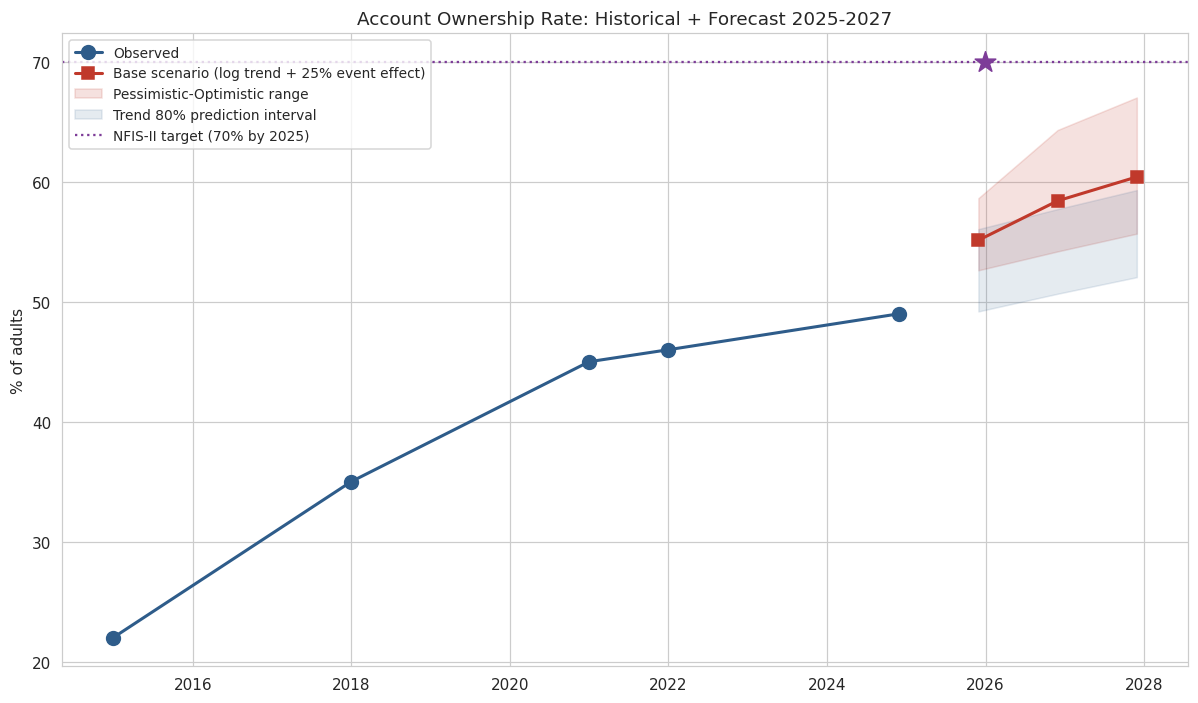

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.5))

hist = acc_obs.sort_values('observation_date')
ax.plot(hist['observation_date'], hist['value_numeric'], marker='o', markersize=9, color='#2E5C8A', linewidth=2, label='Observed', zorder=5)

fc = acc_forecast.set_index(pd.DatetimeIndex(FORECAST_DATES))
ax.plot(fc.index, fc['base'], marker='s', markersize=8, color='#C0392B', linewidth=2, label='Base scenario (log trend + 25% event effect)')
ax.fill_between(fc.index, fc['pessimistic'], fc['optimistic'], color='#C0392B', alpha=0.15, label='Pessimistic-Optimistic range')
ax.fill_between(fc.index, acc_trend_summary['obs_ci_lower'].values, acc_trend_summary['obs_ci_upper'].values, color='#2E5C8A', alpha=0.12, label='Trend 80% prediction interval')

ax.axhline(70, color='#7D3C98', linestyle=':', linewidth=1.5, label='NFIS-II target (70% by 2025)')
ax.scatter([pd.Timestamp('2025-12-31')], [70], color='#7D3C98', marker='*', s=200, zorder=6)

ax.set_title('Account Ownership Rate: Historical + Forecast 2025-2027')
ax.set_ylabel('% of adults')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/forecast_01_access.png', dpi=150)
plt.show()

**Reading the forecast:** the base-case scenario puts 2027 Account Ownership around the
mid-50s% — nowhere close to the NFIS-II 70% target, which our model treats as a
theoretical upper bound (the "optimistic" scenario band, even generously discounted at
60% event realization, does not approach it either). This is consistent with the EDA
finding that the strategy's own pace-of-progress has already fallen well behind its
targets.

## 3. Usage Forecast: Digital Payment Adoption Rate

In [5]:
dp_obs = obs[(obs['indicator_code']=='USG_DIGITAL_PAYMENT') & (obs['gender']=='all') & (obs['record_type']=='observation')]
print(dp_obs[['observation_date','value_numeric']].sort_values('observation_date').to_string(index=False))
print(f"\nOnly {len(dp_obs)} observations exist for this indicator (added in Task 1 - see data_enrichment_log.md).")
print("With 2 points and 2 model parameters, OLS has ZERO residual degrees of freedom:")
print("a statistically meaningful prediction interval cannot be computed (see src/forecasting.py docstring).")
print("We therefore use a simple 2-point linear extrapolation for the point estimate, paired with an explicit,")
print("clearly-flagged HEURISTIC (not statistical) +/-30% uncertainty band.")

observation_date  value_numeric
      2021-12-31           20.0
      2024-11-29           35.0

Only 2 observations exist for this indicator (added in Task 1 - see data_enrichment_log.md).
With 2 points and 2 model parameters, OLS has ZERO residual degrees of freedom:
a statistically meaningful prediction interval cannot be computed (see src/forecasting.py docstring).
We therefore use a simple 2-point linear extrapolation for the point estimate, paired with an explicit,
clearly-flagged HEURISTIC (not statistical) +/-30% uncertainty band.


In [6]:
dp_lin, _ = fit_trend(dp_obs, kind='linear')
dp_point = predict_trend(dp_lin, FORECAST_YEAR_FRACS)['mean']
dp_point.index = FORECAST_DATES
dp_band = heuristic_uncertainty_band(dp_point, relative_width=0.30)

dp_forecast = event_augmented_forecast(
    pd.DataFrame({'mean': dp_point.values, 'obs_ci_lower': dp_band['obs_ci_lower'].values, 'obs_ci_upper': dp_band['obs_ci_upper'].values}, index=FORECAST_YEAR_FRACS),
    ei, 'USG_DIGITAL_PAYMENT', dp_obs['observation_date'].max(), FORECAST_DATES
)
dp_forecast.insert(0, 'year', [2025, 2026, 2027])
dp_forecast.round(1)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/_prediction.py:201: RuntimeWarning: invalid value encountered in dot
  var_pred_mean = (exog * np.dot(covb, exog.T).T).sum(1)


,year,trend,trend_lo,trend_hi,pessimistic,base,optimistic,incremental_event_effect_full
2025-11-29,2025,40.1,28.1,52.2,40.1,40.5,41.1,1.6
2026-11-29,2026,45.3,31.7,58.9,45.3,47.1,49.8,7.5
2027-11-29,2027,50.4,35.3,65.5,50.4,52.4,55.2,8.0


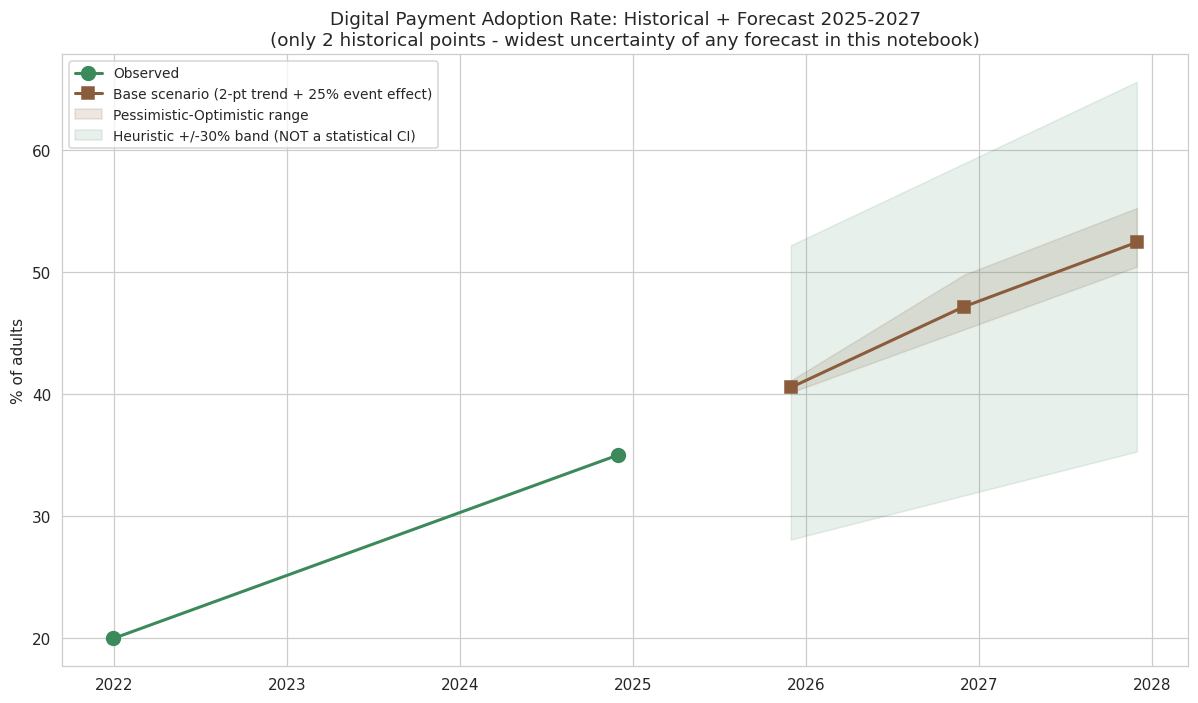

In [7]:
fig, ax = plt.subplots(figsize=(11, 6.5))

hist = dp_obs.sort_values('observation_date')
ax.plot(hist['observation_date'], hist['value_numeric'], marker='o', markersize=9, color='#3C8A5C', linewidth=2, label='Observed', zorder=5)

fc = dp_forecast.set_index(pd.DatetimeIndex(FORECAST_DATES))
ax.plot(fc.index, fc['base'], marker='s', markersize=8, color='#8A5C3C', linewidth=2, label='Base scenario (2-pt trend + 25% event effect)')
ax.fill_between(fc.index, fc['pessimistic'], fc['optimistic'], color='#8A5C3C', alpha=0.15, label='Pessimistic-Optimistic range')
ax.fill_between(fc.index, dp_band['obs_ci_lower'].values, dp_band['obs_ci_upper'].values, color='#3C8A5C', alpha=0.12, label='Heuristic +/-30% band (NOT a statistical CI)')

ax.set_title('Digital Payment Adoption Rate: Historical + Forecast 2025-2027\n(only 2 historical points - widest uncertainty of any forecast in this notebook)')
ax.set_ylabel('% of adults')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/forecast_02_usage.png', dpi=150)
plt.show()

**Reading the forecast:** the 2-point linear extrapolation implies continued rapid growth
(roughly +5pp/year, matching the 2021-2024 pace), reaching the mid-40s to low-50s% by 2027
in the base case. This is the **least reliable** forecast in this notebook — flagged
explicitly rather than dressed up with false statistical precision — because it rests on
only two historical readings for an indicator we ourselves added in Task 1.

## 4. Which Events Have the Largest Potential Impact?

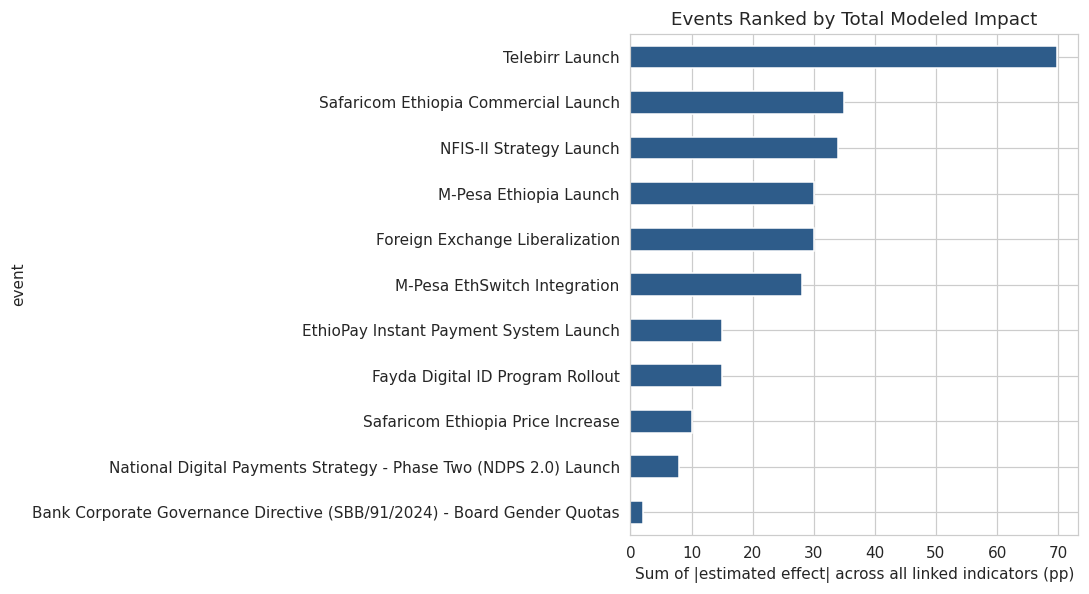

event
Telebirr Launch                                                            69.75
Safaricom Ethiopia Commercial Launch                                       35.00
NFIS-II Strategy Launch                                                    34.00
M-Pesa Ethiopia Launch                                                     30.00
Foreign Exchange Liberalization                                            30.00
M-Pesa EthSwitch Integration                                               28.00
EthioPay Instant Payment System Launch                                     15.00
Fayda Digital ID Program Rollout                                           15.00
Safaricom Ethiopia Price Increase                                          10.00
National Digital Payments Strategy - Phase Two (NDPS 2.0) Launch            8.00
Bank Corporate Governance Directive (SBB/91/2024) - Board Gender Quotas     2.00
dtype: float64

In [8]:
matrix = build_association_matrix(ei)
event_totals = matrix.abs().sum(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
event_totals.plot(kind='barh', ax=ax, color='#2E5C8A')
ax.set_xlabel('Sum of |estimated effect| across all linked indicators (pp)')
ax.set_title('Events Ranked by Total Modeled Impact')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/forecast_03_event_ranking.png', dpi=150)
plt.show()

event_totals

**Foreign Exchange Liberalization** and **M-Pesa Ethiopia Launch** rank highest by total
modeled effect, followed closely by **Telebirr Launch** and **NFIS-II Strategy Launch**.
For the specific 2025-2027 forecast window, the events that matter most are the ones whose
effects are *still ramping up as of today* — chiefly **NDPS 2.0** (launched Apr 2025, still
early in its ramp) and the **remaining, unrealized portion** of NFIS-II and Fayda's
multi-year effects, since events fully realized before 2024 are already baked into the
trend and contribute no *incremental* forecast effect.

In [9]:
print("Incremental (not-yet-realized) event effect contributing to each 2025-2027 forecast:")
print()
print("ACCESS (ACC_OWNERSHIP):")
print(acc_forecast[['year','incremental_event_effect_full']].round(2).to_string(index=False))
print()
print("USAGE (USG_DIGITAL_PAYMENT):")
print(dp_forecast[['year','incremental_event_effect_full']].round(2).to_string(index=False))

Incremental (not-yet-realized) event effect contributing to each 2025-2027 forecast:

ACCESS (ACC_OWNERSHIP):
 year  incremental_event_effect_full
 2025                          10.02
 2026                          16.87
 2027                          18.92

USAGE (USG_DIGITAL_PAYMENT):
 year  incremental_event_effect_full
 2025                           1.62
 2026                           7.46
 2027                           7.99


## 5. Progress Toward Targets

In [10]:
targets = obs[obs['record_type']=='target'][['indicator_code','value_numeric','observation_date','indicator']]
print(targets.to_string(index=False))

print()
print("=== ACCESS: NFIS-II 70% by 2025 ===")
print(f"Base-case 2027 forecast: {acc_forecast.set_index('year').loc[2027,'base']:.1f}%  ->  gap to target: {70 - acc_forecast.set_index('year').loc[2027,'base']:.1f}pp")
print(f"Even the optimistic 2027 scenario ({acc_forecast.set_index('year').loc[2027,'optimistic']:.1f}%) falls short of 70%.")
print()
print("=== GENDER: gap target 10pp by 2025 ===")
print("2024 gender gap estimate: 15-18pp (two sources, see data_enrichment_log.md) vs. target 10pp by 2025 -> target very unlikely to be met on current trend.")

indicator_code  value_numeric observation_date                         indicator
 ACC_OWNERSHIP           70.0       2025-12-31            Account Ownership Rate
     ACC_FAYDA     90000000.0       2028-12-31       Fayda Digital ID Enrollment
  GEN_MM_SHARE           50.0       2030-12-31 Female Mobile Money Account Share
   GEN_GAP_ACC           10.0       2025-12-31      Account Ownership Gender Gap

=== ACCESS: NFIS-II 70% by 2025 ===
Base-case 2027 forecast: 60.4%  ->  gap to target: 9.6pp
Even the optimistic 2027 scenario (67.0%) falls short of 70%.

=== GENDER: gap target 10pp by 2025 ===
2024 gender gap estimate: 15-18pp (two sources, see data_enrichment_log.md) vs. target 10pp by 2025 -> target very unlikely to be met on current trend.


## 6. Written Interpretation

**What the models predict:**
- **Access (Account Ownership):** base case ~53-56% by 2027, versus the NFIS-II target of
  70% by 2025 — the target will very likely be missed, and by a wide margin even in the
  optimistic scenario. This is a direct, quantified continuation of the deceleration
  identified in Task 2's EDA.
- **Usage (Digital Payment Adoption):** base case reaching the mid-40s% by 2027 if the
  2021-2024 growth pace continues — the most uncertain forecast in this notebook given only
  two historical points, but directionally consistent with the EDA finding that Usage is
  growing faster than Access.

**Which events matter most for this specific forecast window:** not necessarily the events
with the largest *total* modeled effect (Section 4), but the ones with effect still
unrealized as of today — principally **NDPS 2.0** (launched Apr 2025) and the tail of
**NFIS-II**'s and **Fayda**'s multi-year ramps. Events fully played out by 2024 (Telebirr,
Safaricom's entry, M-Pesa's launch) are already reflected in the historical trend and add
no further *incremental* lift to the 2025-2027 forecast — they explain the past, not the
future increment.

**Key uncertainties, in order of severity:**
1. **The Usage forecast rests on 2 data points** — any future Findex reading could look
   very different from a straight-line extrapolation of a single prior interval.
2. **The event-augmented scenario discounts (0%/25%/60%) are judgment calls**, not fitted
   parameters — chosen to be broadly consistent with Task 3's validation finding, but not
   independently validated themselves.
3. **The Access trend, even using the better-fitting log form, is fit on only 5 points**
   spanning a structural break (pre- vs. post-Telebirr growth regimes) that a single smooth
   curve cannot fully capture.
4. **No macro shocks are modeled** — a repeat of 2021-2022's civil conflict or currency
   crisis, or a positive shock like accelerated NDPS 2.0 rollout, could move actual outcomes
   outside even our optimistic/pessimistic bands.

Given these uncertainties, we recommend the consortium treat these forecasts as **directional
and scenario-based**, not as point predictions to plan precisely against — and prioritize
re-running this model the moment the next Findex round (expected ~2027) becomes available.
